In [1]:
import numpy as np, matplotlib.pyplot as plt, torch, json, urllib.request, warnings
import torchvision.models as models, torchvision.transforms as transforms
from PIL import Image
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2).eval().to(device)
preprocess = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])

req = urllib.request.Request(
    'https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json',
    headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req) as resp:
    class_names = json.load(resp)

image = Image.open('images/imagenet_peacock.jpg').convert('RGB')
image_arr = np.array(image.resize((224, 224)))
input_tensor = preprocess(image).unsqueeze(0).to(device)


def classify(img_np):
    tensor = preprocess(Image.fromarray(img_np.astype('uint8'))).unsqueeze(0).to(device)
    with torch.no_grad():
        return torch.softmax(model(tensor), dim=1)


probs = classify(image_arr)
top5_probs, top5_classes = probs.topk(5)
target_class = top5_classes[0, 0].item()
target_label = class_names[target_class]

print('Top-5 predictions:')
for k in range(5):
    print(f'  {class_names[top5_classes[0,k].item()]:30s} {top5_probs[0,k].item():.4f}')
print(f'\nPredicted: {target_label} (class {target_class}, confidence {top5_probs[0,0].item():.2%})')

Top-5 predictions:
  peacock                        0.5918
  coucal                         0.0053
  cicada                         0.0012
  ear of corn                    0.0012
  jacamar                        0.0010

Predicted: peacock (class 84, confidence 59.18%)


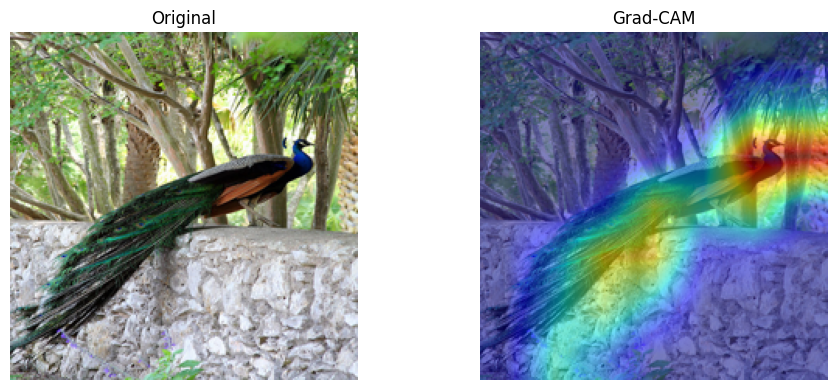

In [2]:
# Grad-CAM saliency map
activations, gradients = {}, {}
model.layer4[-1].register_forward_hook(lambda m,i,o: activations.update(val=o.detach()))
model.layer4[-1].register_full_backward_hook(lambda m,gi,go: gradients.update(val=go[0].detach()))

model.zero_grad()
logits = model(input_tensor)
logits[0, target_class].backward()

weights = gradients['val'].mean(dim=(2,3), keepdim=True)
cam = torch.relu((weights * activations['val']).sum(1, keepdim=True))
cam = torch.nn.functional.interpolate(cam, (224,224), mode='bilinear', align_corners=False)
cam = cam.squeeze().cpu().numpy()
saliency_map = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(image_arr); ax1.set_title('Original'); ax1.axis('off')
ax2.imshow(image_arr); ax2.imshow(saliency_map, cmap='jet', alpha=0.5)
ax2.set_title('Grad-CAM'); ax2.axis('off')
plt.tight_layout(); plt.show()

In [3]:
def perturbation_curve(image, saliency, target_class, n_steps=50, mode='morf'):
    height, width = saliency.shape
    total_pixels = height * width
    flat_saliency = saliency.flatten()
    order = np.argsort(-flat_saliency) if mode == 'morf' else np.argsort(flat_saliency)
    step_size = max(1, total_pixels // n_steps)
    fill_color = image.mean(axis=(0,1)).astype('uint8')
    perturbed = image.copy()
    fractions = [0.0]
    confidences = [classify(image)[0, target_class].item()]
    for s in range(1, n_steps + 1):
        start, end = (s-1)*step_size, min(s*step_size, total_pixels)
        if start >= total_pixels: break
        rows, cols = np.unravel_index(order[start:end], (height, width))
        perturbed[rows, cols] = fill_color
        fractions.append(end / total_pixels)
        confidences.append(classify(perturbed)[0, target_class].item())
    return np.array(fractions), np.array(confidences)

print('Running MoRF...')
morf_fracs, morf_confs = perturbation_curve(image_arr, saliency_map, target_class, mode='morf')
print('Running LeRF...')
lerf_fracs, lerf_confs = perturbation_curve(image_arr, saliency_map, target_class, mode='lerf')
print('Done.')

Running MoRF...
Running LeRF...
Done.


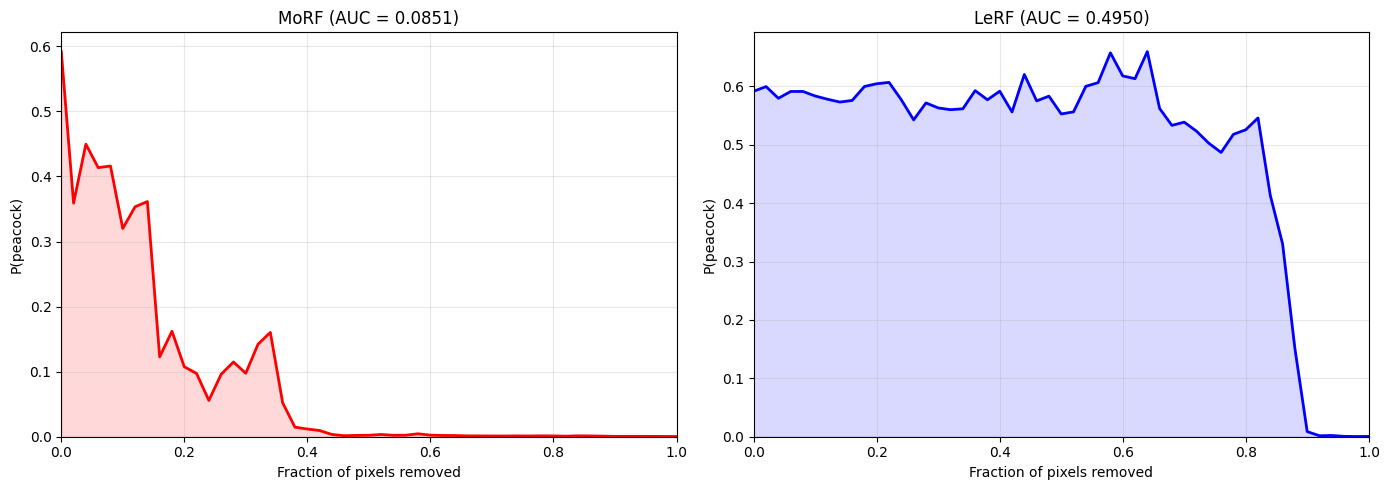

MoRF AUC: 0.0851   LeRF AUC: 0.4950   Gap: 0.4099


In [4]:
morf_auc, lerf_auc = np.trapz(morf_confs, morf_fracs), np.trapz(lerf_confs, lerf_fracs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, fracs, confs, auc, color, title in [
    (ax1, morf_fracs, morf_confs, morf_auc, 'red',  'MoRF'),
    (ax2, lerf_fracs, lerf_confs, lerf_auc, 'blue', 'LeRF')]:
    ax.plot(fracs, confs, color=color, linewidth=2)
    ax.fill_between(fracs, confs, alpha=0.15, color=color)
    ax.set(xlabel='Fraction of pixels removed', ylabel=f'P({target_label})',
           title=f'{title} (AUC = {auc:.4f})', xlim=(0,1), ylim=(0,None))
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/morf_lerf_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'MoRF AUC: {morf_auc:.4f}   LeRF AUC: {lerf_auc:.4f}   Gap: {lerf_auc-morf_auc:.4f}')

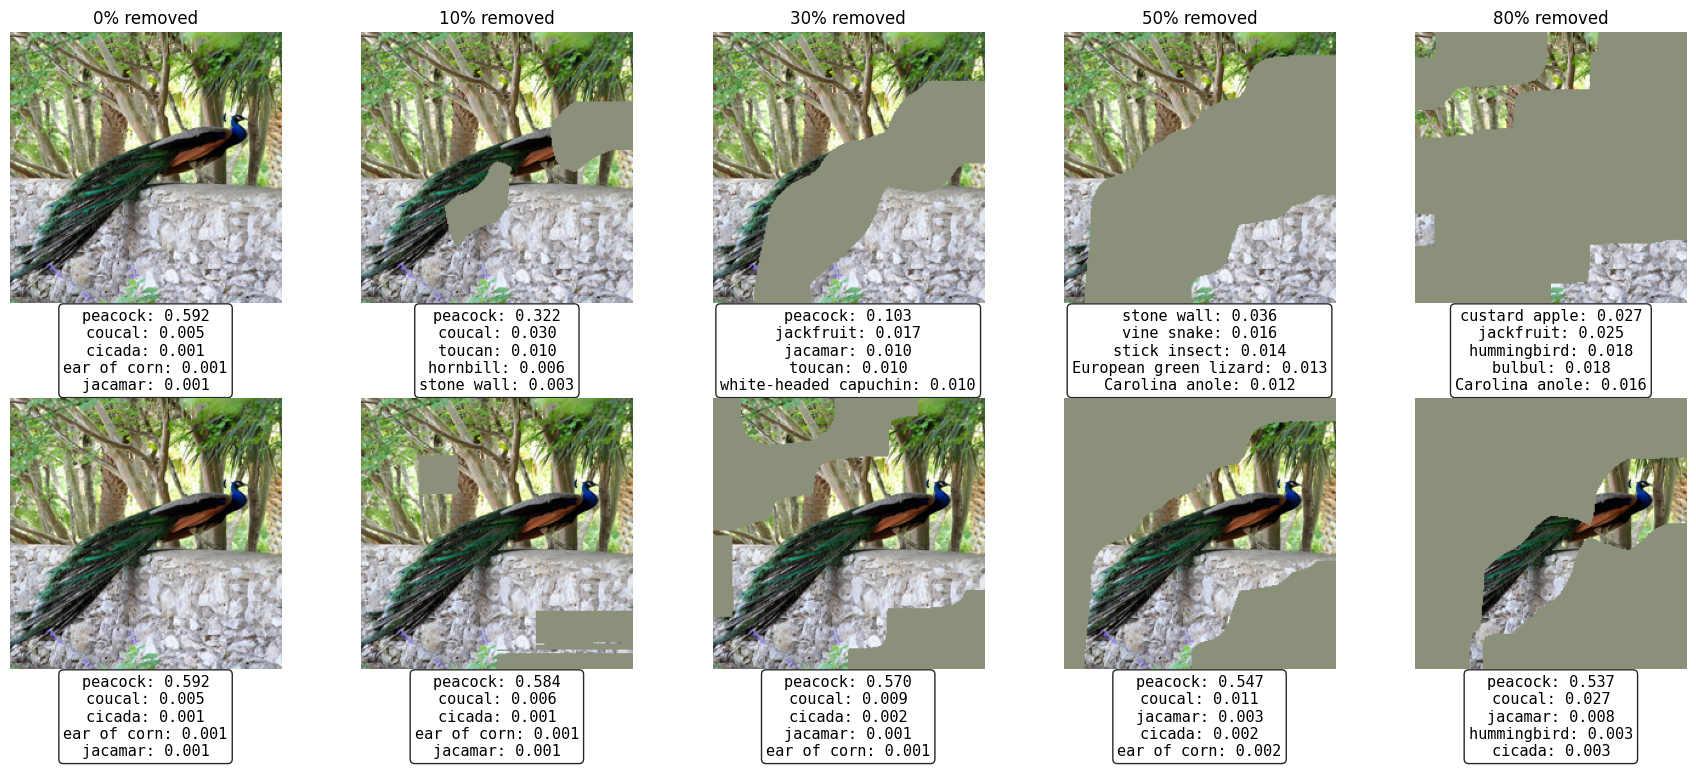

In [9]:
removal_levels = [0.0, 0.1, 0.3, 0.5, 0.8]
height, width = saliency_map.shape
total_pixels = height * width
fill_color = image_arr.mean(axis=(0,1)).astype('uint8')

fig, axes = plt.subplots(2, len(removal_levels), figsize=(3.5*len(removal_levels), 7.5))

for row, (mode, mode_label) in enumerate([('morf','MoRF'), ('lerf','LeRF')]):
    flat_saliency = saliency_map.flatten()
    order = np.argsort(-flat_saliency) if mode == 'morf' else np.argsort(flat_saliency)
    for col, frac in enumerate(removal_levels):
        perturbed = image_arr.copy()
        n_remove = int(frac * total_pixels)
        if n_remove > 0:
            rows, cols = np.unravel_index(order[:n_remove], (height, width))
            perturbed[rows, cols] = fill_color
        top5_probs, top5_classes = classify(perturbed).topk(5)
        pred_text = '\n'.join(
            f'{class_names[top5_classes[0,k].item()]}: {top5_probs[0,k].item():.3f}'
            for k in range(5))
        ax = axes[row, col]
        ax.imshow(perturbed); ax.axis('off')
        ax.text(0.5, -0.02, pred_text, transform=ax.transAxes, fontsize=11,
                ha='center', va='top', family='monospace',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
        if row == 0: ax.set_title(f'{int(frac*100)}% removed', fontsize=12)
        if col == 0: ax.set_ylabel(mode_label, fontsize=13, rotation=90, labelpad=15)

plt.tight_layout(); plt.subplots_adjust(hspace=0.35)
plt.savefig('images/morf_lerf_perturbation.png', dpi=150, bbox_inches='tight')
plt.show()

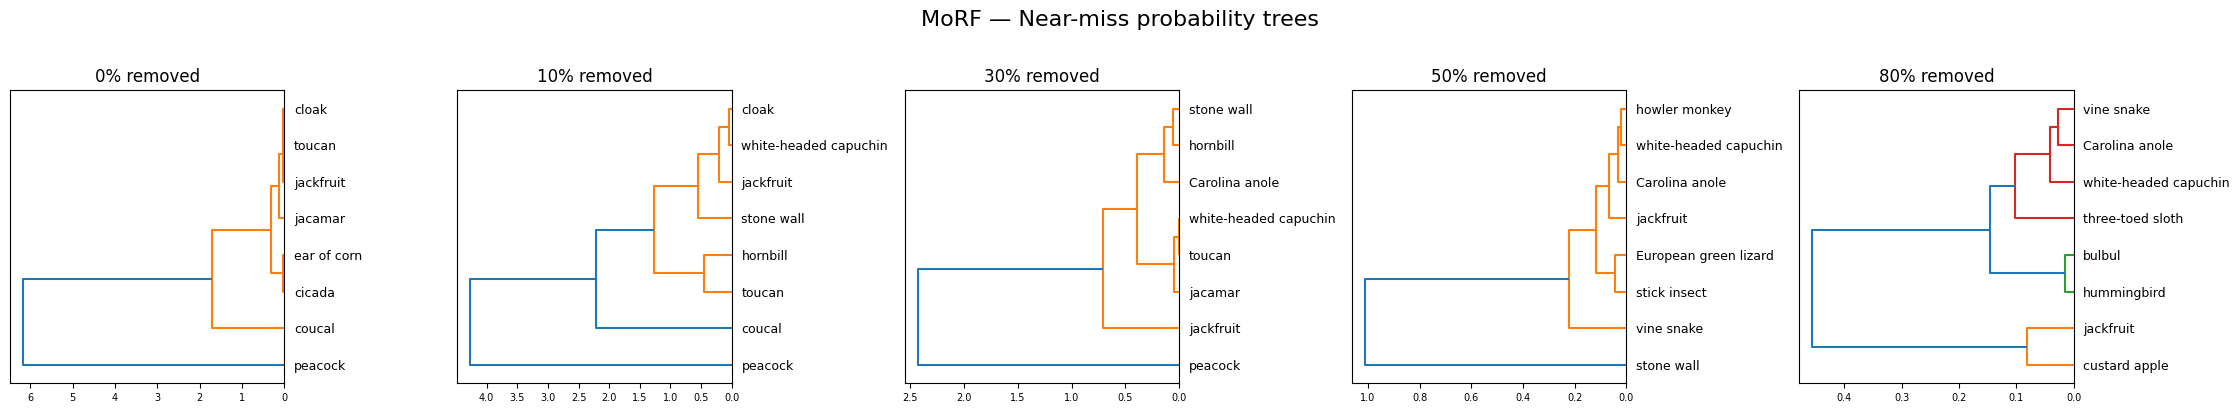

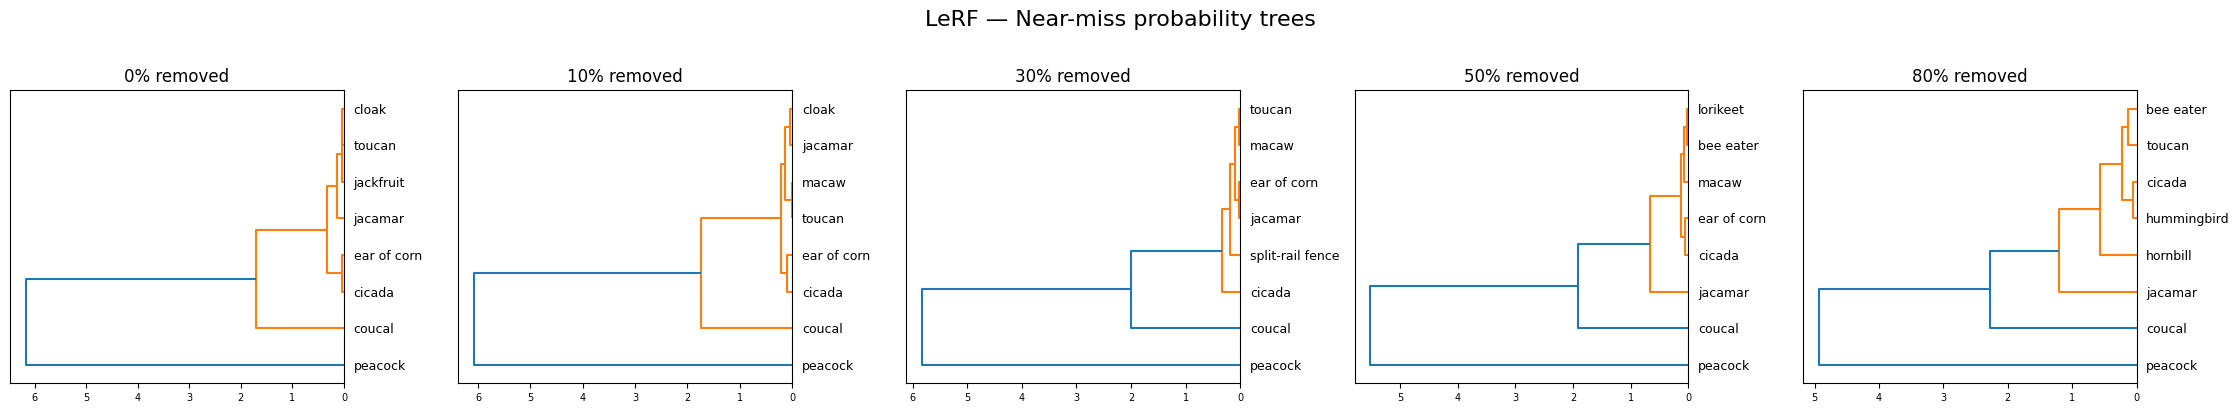

: 

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

TOP_K = 8
removal_levels = [0.0, 0.1, 0.3, 0.5, 0.8]
height, width = saliency_map.shape
total_pixels = height * width
fill_color = image_arr.mean(axis=(0,1)).astype('uint8')

for mode, mode_label in [('morf', 'MoRF'), ('lerf', 'LeRF')]:
    flat_saliency = saliency_map.flatten()
    order = np.argsort(-flat_saliency) if mode == 'morf' else np.argsort(flat_saliency)

    fig, axes = plt.subplots(1, len(removal_levels),
                             figsize=(4.5 * len(removal_levels), 4))
    fig.suptitle(f'{mode_label} — Near-miss probability trees', fontsize=16, y=1.02)

    for col, frac in enumerate(removal_levels):
        perturbed = image_arr.copy()
        n_remove = int(frac * total_pixels)
        if n_remove > 0:
            rows, cols = np.unravel_index(order[:n_remove], (height, width))
            perturbed[rows, cols] = fill_color

        prob_vec = classify(perturbed).squeeze().cpu().numpy()
        top_indices = np.argsort(-prob_vec)[:TOP_K]
        top_probs = prob_vec[top_indices]
        top_labels = [class_names[i] for i in top_indices]

        log_probs = np.log(np.clip(top_probs, 1e-10, None))
        distances = pdist(log_probs.reshape(-1, 1))
        linked = linkage(distances, method='average')

        ax = axes[col]
        dendrogram(linked, labels=top_labels, orientation='left',
                   leaf_font_size=9, ax=ax, color_threshold=0.3 * linked[-1, 2])
        ax.set_title(f'{int(frac*100)}% removed', fontsize=12)
        ax.tick_params(axis='x', labelsize=7)

    plt.tight_layout()
    plt.savefig(f'images/{mode}_dendrograms.png', dpi=150, bbox_inches='tight')
    plt.show()